In [1]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

## 1. Chessboard corner detection

To calibrate the stereo setup, we need to match 3D points on the calibration board with 2D points in each image. The board has 9 × 6 inner corners with 33.6 mm squares, so we define the object points as a grid in the plane Z = 0, scaled to millimetres. Both cameras see the same board, so this one set of points is shared. For every image pair we convert both images to grayscale, detect the inner corners with `cv2.findChessboardCorners`, and refine them to sub-pixel accuracy with `cv2.cornerSubPix`. The refinement isn't strictly necessary, but it improves calibration accuracy. A pair is only kept if the board is found in both images, so the left and right point lists stay matched for the stereo calibration.


In [2]:
"""
Implement the number of vertical and horizontal corners
"""
nb_vertical = 9
nb_horizontal = 6
square_size = 33.6  # mm

# Same board for both cameras -> one set of object points, in mm
objp = np.zeros((nb_horizontal*nb_vertical, 3), np.float32)
objp[:, :2] = np.mgrid[0:nb_vertical, 0:nb_horizontal].T.reshape(-1, 2)
objp *= square_size

# Arrays to store object points and image points from all the image pairs.
objpoints = []        # 3d points in real world space (shared by both cameras)
imgpoints_left = []   # 2d points in left image plane
imgpoints_right = []  # 2d points in right image plane

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

left_images = sorted(glob.glob("rs/left-*.png"))
right_images = sorted(glob.glob("rs/right-*.png"))

assert left_images and len(left_images) == len(right_images)

for left_fname, right_fname in zip(left_images, right_images):
    img_left = cv2.imread(left_fname)
    img_right = cv2.imread(right_fname)

    gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

    ret_left, corners_left = cv2.findChessboardCorners(gray_left, (nb_vertical, nb_horizontal), None)
    ret_right, corners_right = cv2.findChessboardCorners(gray_right, (nb_vertical, nb_horizontal), None)

    # Only keep pairs where the board is found in BOTH images
    if ret_left and ret_right:
        corners_left = cv2.cornerSubPix(gray_left, corners_left, (11, 11), (-1, -1), criteria)
        corners_right = cv2.cornerSubPix(gray_right, corners_right, (11, 11), (-1, -1), criteria)

        objpoints.append(objp)
        imgpoints_left.append(corners_left)
        imgpoints_right.append(corners_right)

        # Draw and display the corners side by side
        cv2.drawChessboardCorners(img_left, (nb_vertical, nb_horizontal), corners_left, ret_left)
        cv2.drawChessboardCorners(img_right, (nb_vertical, nb_horizontal), corners_right, ret_right)
        # cv2.imshow('pair', np.hstack([img_left, img_right]))
        # cv2.waitKey(100)

cv2.destroyAllWindows()

img_size = gray_left.shape[::-1]  # (width, height)
print(f"{len(objpoints)} of {len(left_images)} pairs used")


76 of 76 pairs used


## 2. Individual camera calibration

Each camera is first calibrated on its own with `cv2.calibrateCamera`, using the shared object points and that camera's detected corners. This estimates the intrinsic camera matrix `mtx`, which holds the focal lengths and principal point, and the lens distortion coefficients `dist` (radial and tangential). It also returns the board pose for every image (`rvecs`, `tvecs`) and the RMS reprojection error `ret`, a measure of how well the model fits the detected corners. These intrinsics are the starting point for the stereo calibration, which then only has to find how the two cameras are positioned relative to each other.


In [3]:
ret_left, mtx_left, dist_left, rvecs_left, tvecs_left = cv2.calibrateCamera(objpoints, imgpoints_left, gray_left.shape[::-1], None, None)
ret_right, mtx_right, dist_right, rvecs_right, tvecs_right = cv2.calibrateCamera(objpoints, imgpoints_right, gray_right.shape[::-1], None, None)

## 3. Stereo calibration

`cv2.stereoCalibrate` uses the corner correspondences from both cameras to estimate the relative pose between them: the rotation `R` and translation `T` that take points from the left camera frame to the right camera frame. Because the object points are in millimetres, `T` is also in millimetres, and its length is the baseline used later for depth. The intrinsics from `calibrateCamera` are passed in and kept fixed, which is OpenCV's default (`CALIB_FIX_INTRINSIC`), so only the extrinsics are solved for. The function also returns the essential and fundamental matrices `E` and `F`, which describe the epipolar geometry of the pair, and the RMS reprojection error `ret_stereo` as a measure of calibration quality.


In [4]:
criteria_stereo = (cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS,100,1e-5,)
flags_stereo = cv2.CALIB_FIX_INTRINSIC

ret_stereo, mtx_left, dist_left, mtx_right, dist_right, R, T, E, F = cv2.stereoCalibrate(
    objpoints,          # board points in mm, one per pair
    imgpoints_left,     # corners in left images
    imgpoints_right,    # corners in right images
    mtx_left, dist_left,
    mtx_right, dist_right,
    img_size,
    criteria=criteria_stereo,
    flags=flags_stereo
)

## 4. Stereo rectification

`cv2.stereoRectify` uses the intrinsics of both cameras and the relative pose (`R`, `T`) from `stereoCalibrate` to compute how each camera must be virtually rotated so that the two image planes become coplanar and row-aligned. After rectification, a point in the left image lies on the same row in the right image, so the block matcher only needs to search horizontally. It returns the rotations `R1` and `R2` for each camera, the new projection matrices `P1` and `P2` (which share the focal length `f = P1[0,0]` and encode the baseline in `P2[0,3] = -f·B`), and the disparity-to-depth matrix `Q`.


In [5]:
R1, R2, P1, P2, Q, validPixROI1, validPixROI2 = cv2.stereoRectify(mtx_left, dist_left, mtx_right, dist_right, img_size, R, T)#, alpha=1)

## 5. Undistortion and rectification maps

`cv2.initUndistortRectifyMap` turns the transformations into lookup tables that tell `cv2.remap`, for each pixel in the rectified image, which pixel to sample in the original image. The mapping removes the lens distortion (`mtx`, `dist`) and then applies the rectification (`R1`/`P1` or `R2`/`P2`), so a single remap undistorts and rectifies the image in one step. The maps only depend on the calibration, so they are computed once per camera and reused for all image pairs.


In [6]:
map_left_x, map_left_y = cv2.initUndistortRectifyMap(mtx_left, dist_left, R1, P1, img_size, cv2.CV_32FC1)
map_right_x, map_right_y = cv2.initUndistortRectifyMap(mtx_right, dist_right, R2, P2, img_size, cv2.CV_32FC1)


## 6. Remapping a test pair

Before processing the whole dataset, we apply the maps to a single stereo pair (index 44) as a check. `cv2.remap` builds each rectified image by looking up, for every output pixel, the corresponding position in the original image given by the maps, and bilinear interpolation (`cv2.INTER_LINEAR`) handles positions that fall between pixels. The result is an undistorted and rectified left and right image. We plot the left one to check that straight edges look straight and that no large distortion or unexpected cropping remains.


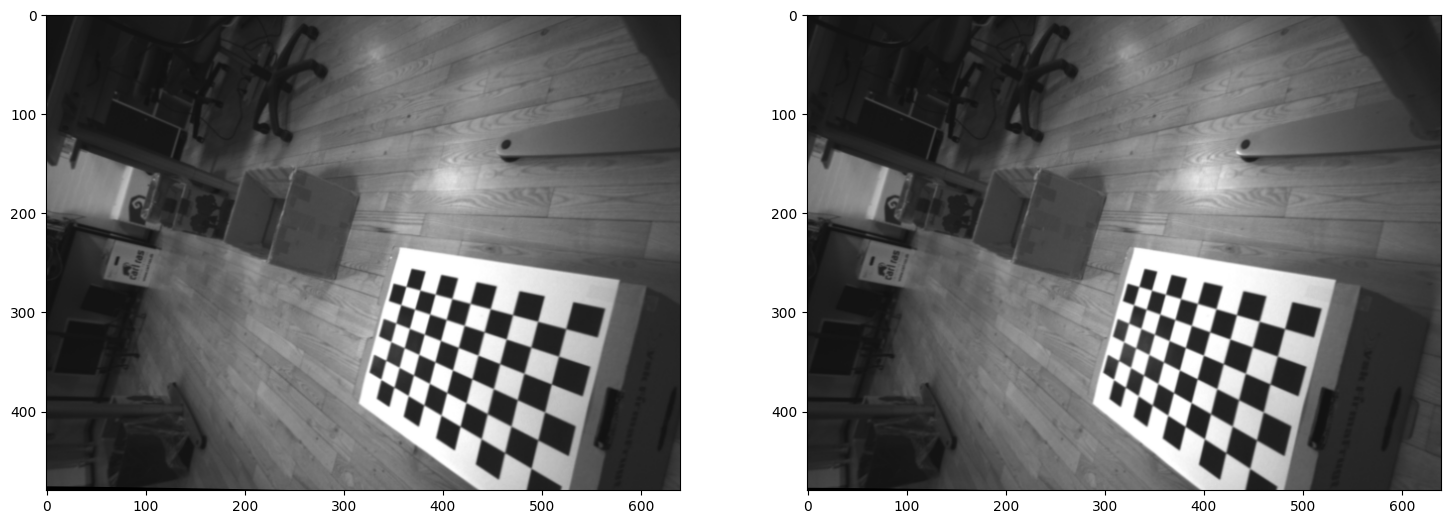

In [7]:
# Test one left and one right
img_left = cv2.imread(left_images[44])
img_right = cv2.imread(right_images[44])

rect_left = cv2.remap(img_left, map_left_x, map_left_y, cv2.INTER_LINEAR)
rect_right = cv2.remap(img_right, map_right_x, map_right_y, cv2.INTER_LINEAR)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,18))
ax[0].imshow(rect_left[...,[2,1,0]])
ax[1].imshow(rect_right[...,[2,1,0]])

#Optional: Loop through all to apply rectification to all images
# Do all the images
# rec_left_all = []
# rect_right_all = []

# for left_fname, right_fname in zip(left_images, right_images):
#     img_left = cv2.imread(left_fname)
#     img_right = cv2.imread(right_fname)

#     rec_left_all.append(cv2.remap(img_left, map_left_x, map_left_y, cv2.INTER_LINEAR))
#     rect_right_all.append(cv2.remap(img_right, map_right_x, map_right_y, cv2.INTER_LINEAR))

## 7. Stereo depth reconstruction

Finally, we apply our own block-matching implementation from last week to the rectified image pair to compute a disparity map. Because the images are rectified, corresponding points lie on the same row, so the search for each block only runs horizontally along that row.


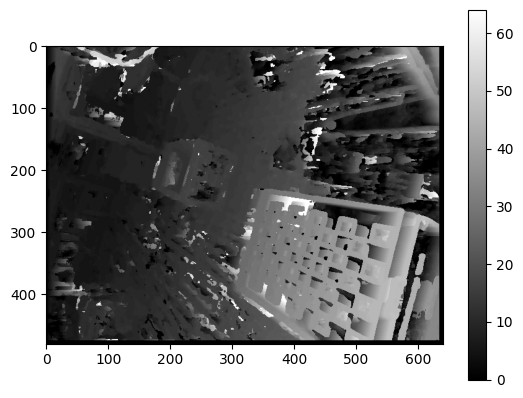

In [8]:
def sad(imageOne, imageTwo):
    if imageOne.shape != imageTwo.shape:
        raise ValueError("Images must be the same size")
    return int(np.abs(imageOne.astype(np.int32) - imageTwo.astype(np.int32)).sum())

def find_in_span(template, span):
    h, w   = template.shape
    scores = []
    for x in range(span.shape[1] - w + 1):
        scores.append(sad(template, span[:, x:x+w]))
    return int(np.argmin(scores)), scores

def matchImage(left, right, win=7, max_d=64):
    diff = np.zeros(left.shape)
    for y in range(left.shape[0] - win + 1):
        for x in range(left.shape[1] - win + 1):
            template = left[y:y+win, x:x+win]
            lo = max(0, x - max_d)
            span = right[y:y+win, lo:x+win] 
            best_x, _ = find_in_span(template, span)
            diff[y, x] = x - (lo + best_x)
    return diff

gray_left = cv2.cvtColor(rect_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(rect_right, cv2.COLOR_BGR2GRAY)

# Calculate result matrix
result = matchImage(gray_left, gray_right)

# Plot result
plt.imshow(result, cmap='gray')
plt.colorbar()
plt.show()
        

Overall, the resulting disparity map is noisy but accurately shows, for example, that the chessboard is closer than the box (higher disparity). 

We see it struglles a bit with the checker board pattern which could be due the repeatable pattern making it harder to match correctly. We also see a lot of noise on the floor where the texture is also similar across the whole surface.


Possible extensions to this work could include converting it to a depth image, as well as identifying the main disparities/depths and clipping the values to certain bands to create a smoother map, like the one seen in the solution to last week's project.

## Now with the "mynteye" images
We can use the same code as above, but we need to change the image paths to the "mynteye" images.

In [9]:
"""
Implement the number of vertical and horizontal corners
"""
nb_vertical = 9
nb_horizontal = 6
square_size = 33.6  # mm

# Same board for both cameras -> one set of object points, in mm
objp = np.zeros((nb_horizontal*nb_vertical, 3), np.float32)
objp[:, :2] = np.mgrid[0:nb_vertical, 0:nb_horizontal].T.reshape(-1, 2)
objp *= square_size

# Arrays to store object points and image points from all the image pairs.
objpoints = []        # 3d points in real world space (shared by both cameras)
imgpoints_left = []   # 2d points in left image plane
imgpoints_right = []  # 2d points in right image plane

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

left_images = sorted(glob.glob("mynteye/left-*.png"))
right_images = sorted(glob.glob("mynteye/right-*.png"))
assert left_images and len(left_images) == len(right_images)

for left_fname, right_fname in zip(left_images, right_images):
    img_left = cv2.imread(left_fname)
    img_right = cv2.imread(right_fname)

    gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

    ret_left, corners_left = cv2.findChessboardCorners(gray_left, (nb_vertical, nb_horizontal), None)
    ret_right, corners_right = cv2.findChessboardCorners(gray_right, (nb_vertical, nb_horizontal), None)

    # Only keep pairs where the board is found in BOTH images
    if ret_left and ret_right:
        corners_left = cv2.cornerSubPix(gray_left, corners_left, (11, 11), (-1, -1), criteria)
        corners_right = cv2.cornerSubPix(gray_right, corners_right, (11, 11), (-1, -1), criteria)

        objpoints.append(objp)
        imgpoints_left.append(corners_left)
        imgpoints_right.append(corners_right)

        # Draw and display the corners side by side
        cv2.drawChessboardCorners(img_left, (nb_vertical, nb_horizontal), corners_left, ret_left)
        cv2.drawChessboardCorners(img_right, (nb_vertical, nb_horizontal), corners_right, ret_right)
        # cv2.imshow('pair', np.hstack([img_left, img_right]))
        # cv2.waitKey(100)

cv2.destroyAllWindows()

img_size = gray_left.shape[::-1]  # (width, height)
print(f"{len(objpoints)} of {len(left_images)} pairs used")


50 of 50 pairs used


In [10]:
ret_left, mtx_left, dist_left, rvecs_left, tvecs_left = cv2.calibrateCamera(objpoints, imgpoints_left, gray_left.shape[::-1], None, None)
ret_right, mtx_right, dist_right, rvecs_right, tvecs_right = cv2.calibrateCamera(objpoints, imgpoints_right, gray_right.shape[::-1], None, None)


In [11]:
criteria_stereo = (cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS,100,1e-5,)
flags_stereo = cv2.CALIB_FIX_INTRINSIC

ret_stereo, mtx_left, dist_left, mtx_right, dist_right, R, T, E, F = cv2.stereoCalibrate(
    objpoints,          # board points in mm, one per pair
    imgpoints_left,     # corners in left images
    imgpoints_right,    # corners in right images
    mtx_left, dist_left,
    mtx_right, dist_right,
    img_size,
    criteria=criteria_stereo,
    flags=flags_stereo
)

In [12]:
R1, R2, P1, P2, Q, validPixROI1, validPixROI2 = cv2.stereoRectify(mtx_left, dist_left, mtx_right, dist_right, img_size, R, T, alpha=0)

In [13]:
map_left_x, map_left_y = cv2.initUndistortRectifyMap(mtx_left, dist_left, R1, P1, img_size, cv2.CV_32FC1)
map_right_x, map_right_y = cv2.initUndistortRectifyMap(mtx_right, dist_right, R2, P2, img_size, cv2.CV_32FC1)

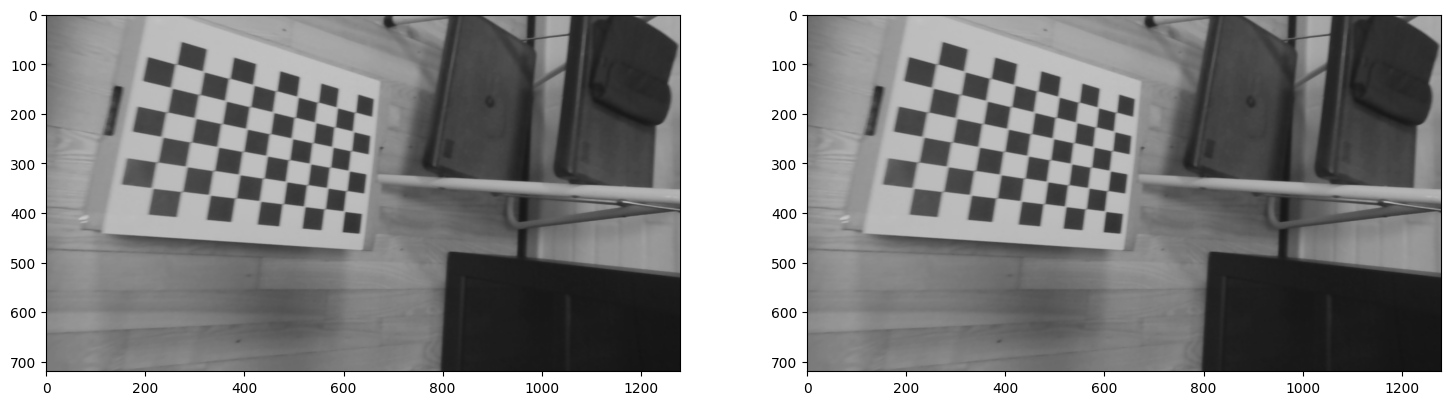

In [14]:
# Test one left and one right
img_left = cv2.imread(left_images[38])
img_right = cv2.imread(right_images[38])

rect_left = cv2.remap(img_left, map_left_x, map_left_y, cv2.INTER_LINEAR)
rect_right = cv2.remap(img_right, map_right_x, map_right_y, cv2.INTER_LINEAR)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,18))
ax[0].imshow(rect_left[...,[2,1,0]])
ax[1].imshow(rect_right[...,[2,1,0]])

plt.imshow(rect_left)

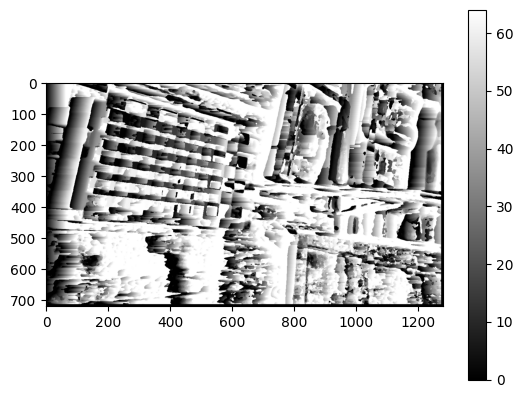

In [ ]:
gray_left = cv2.cvtColor(rect_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(rect_right, cv2.COLOR_BGR2GRAY)

# Calculate result matrix
result = matchImage(gray_left, gray_right)

# Plot result
plt.imshow(result, cmap='gray')
plt.colorbar()
plt.show()

Now this disparity map for "mynteye" seems to perform much worse than the "rs". It does however still capture some shapes from the original images like the checkerboard pattern and the two levels of the staircase/chair on the right.

While the "noise" in this disparity map seems more structured, the image does contain several difficult areas that would make it hard to match the correct points:
- The floor in the bottom left part of the image is of similar structur and with horizontal edges making it hard for our "horizontal scanner" to find the correct match.
- The checkerboard is hard in the same way as the previous picture, furthermore the pattern is also oriented more horizontal/vertical than the previous.
- The uniform black surfaces of the staircase/chair and bottom right black box are hard regions to match.

AI Disclaimer: Claude was used to assist in writing and revising descriptions, adding comments, and explaining some documentation/function I/O.